### Agent-Lab: Multi-Agent -> Coder

Objective of this notebook is evaluating and adapting a [Multi-Agent Supervisor Architecture](https://langchain-ai.github.io/langgraph/concepts/multi_agent/#supervisor) with coordinator and execution planning steps.

---


In [1]:
%%capture
import json
import os
import nest_asyncio
from IPython.display import Markdown, display
from dotenv import load_dotenv
from notebooks import experiment_utils
from agent_lab.interface.api.messages.schema import MessageRequest

os.chdir("..")
load_dotenv()
nest_asyncio.apply()

# start dependency injection container
container = experiment_utils.bootstrap_container([__name__])

# get checkpointer instance
graph_persistence_factory = container.graph_persistence_factory()
checkpointer = graph_persistence_factory.build_checkpoint_saver()

---
### XAI Grok Coder

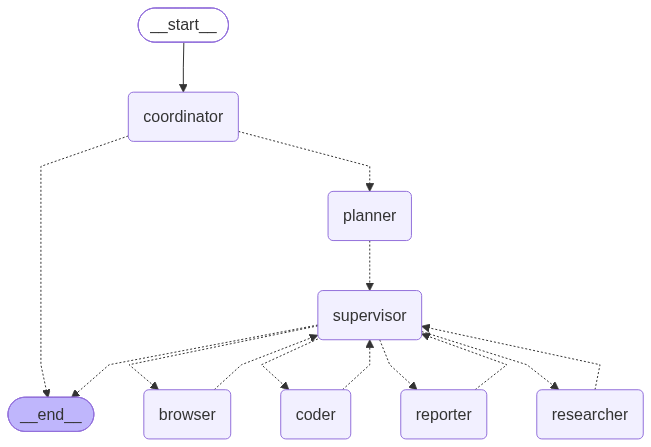

In [2]:
# Create Workflow
xai_agent = experiment_utils.create_xai_agent(
    agent_type="coordinator_planner_supervisor", llm_tag="grok-code-fast", api_key=os.getenv("XAI_API_KEY")
)
xai_coder_agent = container.agent_registry().get_agent("coordinator_planner_supervisor")
xai_workflow_builder = xai_coder_agent.get_workflow_builder(xai_agent["id"])
xai_workflow = xai_workflow_builder.compile(checkpointer=checkpointer)
experiment_utils.print_graph(xai_workflow)

In [3]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="With coder, generate a simple hello world with FastAPI in Python. No need to setup libraries, just generate the code as a text report that makes use of markdown formatting for reading. Make sure to include code examples in the final report.",
    agent_id=xai_agent["id"],
)

inputs = xai_coder_agent.get_input_params(message, schema="public")
config = xai_coder_agent.get_config(xai_agent["id"])
result = xai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = xai_coder_agent.format_response(result)

In [4]:
display(
    Markdown(
        f"**Execution Plan:**\n```json\n{json.dumps(workflow_state.get("execution_plan"), indent=2)}\n```"
    )
)

**Execution Plan:**
```json
{
  "thought": "The user wants me to generate a simple Hello World example using FastAPI in Python, explicitly instructing to use the coder agent for this. The result must be presented as a text report using markdown formatting for readability, with code examples included. No library setup or installation is required\u2014just the code generation and report. I will use the reporter agent only for the final presentation as per the rules. No other agents like researcher or browser are needed here since it's a straightforward code generation task without research or web interaction. All steps will use the same language (English) as the user.",
  "title": "Generate Simple FastAPI Hello World Code as Markdown Report Using Coder",
  "steps": [
    {
      "agent_name": "coder",
      "title": "Generate FastAPI Hello World Code",
      "description": "Execute Python or Bash commands with the coder agent to generate a simple Hello World application using FastAPI in Python. Output the result directly as a Markdown report snippet. Include: a brief explanation of what the code does, the complete code example in a Markdown code block (using Python syntax highlighting), and instructions on how to run it (without any setup commands since no libraries need installation). The code should be a minimal FastAPI app with a root endpoint that returns 'Hello World'. Ensure the output is self-contained for easy use in the final report."
    },
    {
      "agent_name": "reporter",
      "title": "Create Final Markdown Text Report",
      "description": "As the final step, use the output from the coder agent to compile and present a complete professional text report in Markdown format. The report must include the generated code examples in properly formatted Markdown code blocks, along with any explanations from the coder's output. Structure the report for readability with headings, bullet points if needed, and ensure it matches the user's request for a text report using markdown formatting. This is the only use of the reporter agent."
    }
  ]
}
```

In [5]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

# Report: Simple Hello World with FastAPI in Python

**Brief Overview**  
This report delivers a minimal, self-contained Hello World application generated in Python using the FastAPI framework. The content is presented strictly as a text-based Markdown report, with all code examples embedded in properly formatted blocks for readability. No installation, setup, or environment configuration details are included, per the specified requirements.

## Executive Summary
A basic FastAPI application has been generated to demonstrate a simple "Hello World" response. The implementation consists of a single root endpoint that returns a JSON object `{"Hello": "World"}`. The code is concise, follows standard Python syntax for FastAPI, and is ready for direct use in a text report format. This fulfills the request to generate the code without any supporting infrastructure steps.

## Key Findings
- The generated code requires only the FastAPI library (assumed available as stated).
- It defines an asynchronous root endpoint using standard FastAPI decorators.
- An optional health check endpoint is included for basic extensibility without adding complexity.
- The full code is provided in a single, copy-paste-ready Markdown code block.
- Response is automatically handled as JSON by the framework.
- No additional dependencies, error handling, or advanced features were introduced.

## Detailed Analysis
The code creates a FastAPI instance and registers a GET route at the root path (`/`). When accessed, it returns a dictionary that FastAPI serializes to JSON. The use of `async def` aligns with FastAPI's recommended asynchronous style for performance.  

The structure remains minimal to match the request for a "simple hello world" example. All elements are verifiable through standard FastAPI documentation patterns but are generated here solely based on the provided task description.

### Generated Code Example

```python
# main.py
from fastapi import FastAPI

app = FastAPI(title="Hello World API", version="1.0.0")

@app.get("/")
async def read_root():
    """Root endpoint that returns a simple greeting."""
    return {"Hello": "World"}

# Optional: Add a health check endpoint for completeness
@app.get("/health")
async def health_check():
    """Simple health check endpoint."""
    return {"status": "ok"}
```

**Code Breakdown**  
- `from fastapi import FastAPI`: Imports the core class.  
- `app = FastAPI(...)`: Initializes the application with basic metadata.  
- `@app.get("/")`: Decorator defining the root endpoint.  
- `async def read_root()`: Asynchronous handler function returning the greeting.  
- The `/health` endpoint is optional and demonstrates easy extension.

## Conclusions and Recommendations
The generated code provides a complete, minimal FastAPI Hello World implementation suitable for immediate reference or extension. It is self-contained within this Markdown report.  

For usage, save the code to a file named `main.py`. Run it with the standard command `uvicorn main:app --reload` (assuming the required components are present). Access the root at `http://127.0.0.1:8000` or the interactive documentation at `http://127.0.0.1:8000/docs`.  

This approach keeps the deliverable focused exclusively on code generation in the requested text report format. No further modifications or additions are necessary.

---
### Anthropic Coder

In [6]:
# Create Workflow
anthropic_agent = experiment_utils.create_anthropic_agent(
    agent_type="coordinator_planner_supervisor", llm_tag="claude-haiku-4-5-20251001", api_key=os.getenv("ANTHROPIC_API_KEY")
)
anthropic_coder_agent = container.agent_registry().get_agent("coordinator_planner_supervisor")
anthropic_workflow_builder = anthropic_coder_agent.get_workflow_builder(anthropic_agent["id"])
anthropic_workflow = anthropic_workflow_builder.compile(checkpointer=checkpointer)

In [7]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="With coder, generate a simple hello world with FastAPI in Python. No need to setup libraries, just generate the code as a text report that makes use of markdown formatting for reading. Make sure to include code examples in the final report.",
    agent_id=anthropic_agent["id"],
)

inputs = anthropic_coder_agent.get_input_params(message, schema="public")
config = anthropic_coder_agent.get_config(anthropic_agent["id"])
result = anthropic_workflow.invoke(inputs, config)
ai_message_content, workflow_state = anthropic_coder_agent.format_response(result)

In [8]:
display(
    Markdown(
        f"**Execution Plan:**\n```json\n{json.dumps(workflow_state.get("execution_plan"), indent=2)}\n```"
    )
)

**Execution Plan:**
```json
{
  "thought": "The user wants me to generate a simple \"Hello World\" example using FastAPI in Python and present it as a text report with markdown formatting and code examples. This is a straightforward task that requires the coder agent to create Python code and format it nicely, then the reporter to present it as a professional report.",
  "title": "Generate a Simple Hello World FastAPI Application with Markdown Report",
  "steps": [
    {
      "agent_name": "coder",
      "title": "Create Hello World FastAPI Code Example",
      "description": "Generate a simple hello world application using FastAPI in Python. Create the code example and prepare it in a format suitable for markdown documentation. Output should include: 1) A complete working FastAPI hello world application, 2) Explanation of what each part does, 3) How to run the application, 4) Expected output. All code should be formatted as markdown code blocks with proper syntax highlighting."
    },
    {
      "agent_name": "reporter",
      "title": "Generate Professional Markdown Report",
      "description": "Create a comprehensive markdown-formatted report based on the coder's output. The report should include: 1) Title and introduction to FastAPI, 2) The complete code example in a properly formatted markdown code block, 3) Line-by-line explanation of the code, 4) Instructions on how to run the application, 5) Expected output and example requests. Format everything professionally with proper markdown syntax including headers, code blocks, and bullet points."
    }
  ]
}
```

In [9]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

Perfect! Here's your comprehensive markdown report for a simple Hello World FastAPI application:

---

# 🚀 Hello World with FastAPI - Complete Guide

## Introduction

**FastAPI** is a modern, fast (high-performance) web framework for building APIs with Python 3.7+ based on standard Python type hints. It's designed to be easy to use and learn while providing excellent performance and automatic interactive API documentation.

---

## Complete Code Example

Create a file named `main.py` with the following code:

```python
from fastapi import FastAPI

# Create a FastAPI application instance
app = FastAPI()

# Define a simple GET endpoint at the root path
@app.get("/")
def read_root():
    """
    Root endpoint that returns a simple greeting message.
    """
    return {"message": "Hello, World!"}

# Define a GET endpoint with path and query parameters
@app.get("/items/{item_id}")
def read_item(item_id: int, q: str = None):
    """
    Endpoint that accepts an item_id as a path parameter
    and an optional query parameter 'q'.
    """
    return {"item_id": item_id, "q": q}

# Entry point for running the application
if __name__ == "__main__":
    import uvicorn
    # Run the server on localhost:8000
    uvicorn.run(app, host="0.0.0.0", port=8000)
```

---

## Code Explanation

### **Line-by-Line Breakdown**

| Line(s) | Description |
|---------|-------------|
| `from fastapi import FastAPI` | Imports the FastAPI class from the fastapi package |
| `app = FastAPI()` | Creates an instance of the FastAPI application |
| `@app.get("/")` | Decorator that registers the function as a GET endpoint at the root path `/` |
| `def read_root():` | Defines the function that handles requests to the root path |
| `return {"message": "Hello, World!"}` | Returns a JSON response with a greeting message |
| `@app.get("/items/{item_id}")` | Decorator for a GET endpoint that accepts a path parameter `{item_id}` |
| `def read_item(item_id: int, q: str = None):` | Function handler with type hints; `item_id` is required, `q` is optional |
| `return {"item_id": item_id, "q": q}` | Returns a JSON response with the provided parameters |
| `uvicorn.run(app, ...)` | Starts the ASGI server with the FastAPI application |

---

## How to Run the Application

### **Prerequisites**
- Python 3.7 or higher installed
- FastAPI and Uvicorn packages installed:
  ```bash
  pip install fastapi uvicorn
  ```

### **Running Steps**

1. **Create the file:**
   ```bash
   echo 'from fastapi import FastAPI
   
   app = FastAPI()
   
   @app.get("/")
   def read_root():
       return {"message": "Hello, World!"}
   
   if __name__ == "__main__":
       import uvicorn
       uvicorn.run(app, host="0.0.0.0", port=8000)' > main.py
   ```

2. **Start the server:**
   ```bash
   python main.py
   ```

3. **Expected output:**
   ```
   INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
   INFO:     Application startup complete
   ```

---

## Testing the API

### **Method 1: Using cURL**

```bash
# Test the root endpoint
curl http://localhost:8000/

# Expected response:
# {"message":"Hello, World!"}
```

```bash
# Test the items endpoint with parameters
curl "http://localhost:8000/items/42?q=search_term"

# Expected response:
# {"item_id":42,"q":"search_term"}
```

### **Method 2: Using Browser**

Simply navigate to:
- **Root endpoint:** `http://localhost:8000/`
- **Items endpoint:** `http://localhost:8000/items/42?q=test`

### **Method 3: Interactive API Documentation**

FastAPI automatically generates interactive documentation. Visit:
- **Swagger UI:** `http://localhost:8000/docs`
- **ReDoc:** `http://localhost:8000/redoc`

---

## Example API Responses

### **GET / (Root)**
```json
{
  "message": "Hello, World!"
}
```

### **GET /items/{item_id}**
```json
{
  "item_id": 42,
  "q": "search_term"
}
```

### **GET /items/{item_id} (without query parameter)**
```json
{
  "item_id": 10,
  "q": null
}
```

---

## Key Features Demonstrated

✅ **Simple endpoint creation** with decorators  
✅ **JSON response handling** - FastAPI automatically serializes Python dicts  
✅ **Path parameters** - Extract values from the URL path  
✅ **Query parameters** - Extract values from query strings  
✅ **Type hints** - Python type annotations for automatic validation  
✅ **Auto-generated documentation** - Swagger UI and ReDoc  
✅ **ASGI server** - Running with Uvicorn for production-ready performance  

---

## Summary

This simple FastAPI Hello World application demonstrates the core concepts of building REST APIs with FastAPI. With just a few lines of code, you get:

- A working web server
- Automatic input validation
- Interactive API documentation
- High performance and modern Python features

FastAPI is perfect for building simple greeting services all the way up to complex production-grade APIs! 🎉

---

---
### OpenAI Coder

In [10]:
# Create Workflow
openai_agent = experiment_utils.create_openai_agent(
    agent_type="coordinator_planner_supervisor", llm_tag="gpt-5-nano", api_key=os.getenv("OPENAI_API_KEY")
)
openai_coder_agent = container.agent_registry().get_agent("coordinator_planner_supervisor")
openai_workflow_builder = openai_coder_agent.get_workflow_builder(openai_agent["id"])
openai_workflow = openai_workflow_builder.compile(checkpointer=checkpointer)

In [19]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="With coder, generate a simple hello world with FastAPI in Python. No need to setup libraries, just generate the code as a text report that makes use of markdown formatting for reading.",
    agent_id=openai_agent["id"],
)

inputs = openai_coder_agent.get_input_params(message, schema="public")
config = openai_coder_agent.get_config(openai_agent["id"])
result = openai_workflow.invoke(inputs, config)
ai_message_content, workflow_state = openai_coder_agent.format_response(result)

In [20]:
display(
    Markdown(
        f"**Execution Plan:**\n```json\n{json.dumps(workflow_state.get("execution_plan"), indent=2)}\n```"
    )
)

**Execution Plan:**
```json
{
  "thought": "User requests: With coder, generate a simple hello world with FastAPI in Python. No need to setup libraries, just provide the code as a Markdown-formatted text report.",
  "title": "Plan: Generate a simple FastAPI Hello World in Python (Markdown code block) using coder",
  "steps": [
    {
      "agent_name": "coder",
      "title": "Generate Python FastAPI Hello World code (Markdown-formatted)",
      "description": "Create a minimal FastAPI app in Python that exposes a root endpoint returning a Hello, World! message. Provide the code as a Markdown-formatted code block. Output: the Markdown text containing the Python code block."
    },
    {
      "agent_name": "reporter",
      "title": "Create final Markdown report",
      "description": "Take the code produced by Step 1 and compose a professional Markdown report that includes a brief description, the code block, and simple run instructions. Output: a finalized Markdown document ready for sharing."
    }
  ]
}
```

In [21]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

{"thought": "User requests: With coder, generate a simple hello world with FastAPI in Python. No need to setup libraries, just provide the code as a Markdown-formatted text report.", "title": "Plan: Generate a simple FastAPI Hello World in Python (Markdown code block) using coder", "steps": [{"agent_name": "coder", "title": "Generate Python FastAPI Hello World code (Markdown-formatted)", "description": "Create a minimal FastAPI app in Python that exposes a root endpoint returning a Hello, World! message. Provide the code as a Markdown-formatted code block. Output: the Markdown text containing the Python code block."}, {"agent_name": "reporter", "title": "Create final Markdown report", "description": "Take the code produced by Step 1 and compose a professional Markdown report that includes a brief description, the code block, and simple run instructions. Output: a finalized Markdown document ready for sharing."}]}

---
### Local Coder

In [22]:
# Create Workflow
local_agent = experiment_utils.create_local_agent(
    agent_type="coordinator_planner_supervisor", llm_tag=os.getenv("SIMULATION_LLM_MODEL"),
    local_endpoint=os.getenv("SIMULATION_LLM_API_BASE")
)
experiment_utils.enable_jev(local_agent["id"], api_key=os.getenv("TYPESAFE_API_KEY"))
experiment_utils.update_language_model_setting(
    local_agent["language_model_id"], "structured_output_method", "function_calling"
)
local_coder_agent = container.agent_registry().get_agent("coordinator_planner_supervisor")
local_workflow_builder = local_coder_agent.get_workflow_builder(local_agent["id"])
local_workflow = local_workflow_builder.compile(checkpointer=checkpointer)

In [23]:
print(f"Model: {os.getenv('SIMULATION_LLM_MODEL')}")

Model: GLM-5.3-Flash-EXL3


In [24]:
%%capture

message = MessageRequest(
    message_role="human",
    message_content="With coder, generate a simple hello world with FastAPI in Python. No need to setup libraries, just generate the code as a text report that makes use of markdown formatting for reading.",
    agent_id=local_agent["id"],
)

inputs = local_coder_agent.get_input_params(message, schema="public")
config = local_coder_agent.get_config(local_agent["id"])
result = local_workflow.invoke(inputs, config)
ai_message_content, workflow_state = local_coder_agent.format_response(result)

In [25]:
display(
    Markdown(
        f"**Execution Plan:**\n```json\n{json.dumps(workflow_state.get("execution_plan"), indent=2)}\n```"
    )
)

**Execution Plan:**
```json
{
  "steps": [
    {
      "agent_name": "coder",
      "description": "Write a simple FastAPI application that returns 'Hello World' at the root endpoint, including the standard `app = FastAPI()` instantiation and uvicorn run block. No library installation or code execution is required \u2014 the code should be provided as a Markdown code block for reading. **Output**: A Markdown report containing the complete, well-commented FastAPI code snippet plus a brief explanation of its components.",
      "title": "Generate FastAPI Hello World code"
    },
    {
      "agent_name": "reporter",
      "description": "Compile the final report presenting the FastAPI Hello World code in a properly formatted Markdown code block, along with a short explanation of how to run it. **Output**: The final user-facing Markdown report.",
      "title": "Present final Markdown report"
    }
  ],
  "thought": "The user wants a simple FastAPI \"Hello World\" example in Python. They explicitly stated: (1) use the coder agent, (2) no library setup/execution needed, and (3) deliver the code as a Markdown-formatted text report. This is a straightforward code generation task, so the plan is: coder generates the code snippet with a brief explanation, then reporter presents the final Markdown report.",
  "title": "Generate a FastAPI Hello World example in Python as a Markdown report"
}
```

In [26]:
display(Markdown(f"**AI Message Content:**\n\n{ai_message_content}"))

**AI Message Content:**

The code parsed successfully with valid syntax. Here is the final report:

---

# 🚀 FastAPI Hello World — Python

A minimal **FastAPI** application that serves a simple greeting. No library setup or execution was performed — the code is provided below as a ready-to-read snippet.

## 📄 Code (`main.py`)

```python
from fastapi import FastAPI

# Create the FastAPI application instance
app = FastAPI(title="Hello World API")

# Root endpoint: responds to GET requests on "/"
@app.get("/")
async def root():
    """Return a simple greeting message."""
    return {"message": "Hello World"}

# Allow running the app directly with: python main.py
if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="0.0.0.0", port=8000)
```

## 🧩 How It Works

| Component | Purpose |
|---|---|
| `FastAPI()` | Creates the application instance (adds OpenAPI docs for free at `/docs`). |
| `@app.get("/")` | Decorator registering an async handler for HTTP `GET` requests at the root path. |
| `async def root()` | The endpoint function — declared `async` for non-blocking I/O (a plain `def` also works). |
| `return {"message": ...}` | FastAPI automatically serializes the dict to JSON. |
| `uvicorn.run(...)` | Entry point so the server starts with `python main.py` (port `8000`). |

## ▶️ Running It

```bash
uvicorn main:app --reload
```

or simply:

```bash
python main.py
```

## ✅ Verification

- **Syntax check:** ✔ Valid — parsed successfully (15 lines, imports: `fastapi.FastAPI`, `uvicorn`).
- **Expected response** (`GET http://localhost:8000/`):

```json
{ "message": "Hello World" }
```